In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path
import os

In [2]:
WD_PATH = Path(f"{os.getcwd()}")
print(WD_PATH)

/home/awelch/GIPL/warming_experiment_1C/spin_up


In [5]:
def find_stable_year(df, depth_col):
    days_in_year = 365  # Assuming non-leap years for simplicity
    threshold = 0.1

    for start_year in range(len(df) // days_in_year - 1):  # Ensure we have at least two full years of data
        start_index = start_year * days_in_year
        stable = True

        for day in range(days_in_year):
            current_year_temp = df.iloc[start_index + day][depth_col]
            next_year_temp = df.iloc[start_index + days_in_year + day][depth_col]

            if abs(current_year_temp - next_year_temp) >= threshold:
                stable = False
                break

        if stable:
            return start_year

    return None

def check_stability_in_year(df, year, depth_col):
    days_in_year = 365
    threshold = 0.1
    start_index = year * days_in_year

    for day in range(days_in_year):
        current_year_temp = df.iloc[start_index + day][depth_col]
        next_year_temp = df.iloc[start_index + days_in_year + day][depth_col]

        if abs(current_year_temp - next_year_temp) >= threshold:
            return False

    return True

# Load your data (adjust the file path as needed)
calc_header = ['id', 'time', 'Tair', 'snow', '0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m']
temperature_data = pd.read_csv(WD_PATH/'out/result.txt', sep=r'\s+', names=calc_header)

# Dictionary to store results
stable_years = {}

# Loop through each depth column and apply the function
for depth_col in calc_header[4:]:  # From column 4 to 10
    stable_year = find_stable_year(temperature_data, depth_col)
    
    if stable_year is not None:
        stable_years[depth_col] = stable_year
        print(f"Stable year found for depth {depth_col}: Year {stable_year + 1}")
    else:
        print(f"No stable year found for depth {depth_col}")

# Find the last year to reach stability
if stable_years:
    last_stable_year = max(stable_years.values())
    print(f"\nThe last year to reach stability was Year {last_stable_year + 1}")

    # Check if all depths are stable in the last stable year
    all_stable_in_last_year = True
    for depth_col in calc_header[4:]:
        if check_stability_in_year(temperature_data, last_stable_year, depth_col):
            print(f"Depth {depth_col} is stable in Year {last_stable_year + 1}")
        else:
            print(f"Depth {depth_col} is NOT stable in Year {last_stable_year + 1}")
            all_stable_in_last_year = False

    if all_stable_in_last_year:
        print(f"\nAll depths are confirmed stable in Year {last_stable_year + 1}")
    else:
        print(f"\nNot all depths are stable in Year {last_stable_year + 1}")
else:
    print("No stable years found for any depth")

Stable year found for depth 0.01m: Year 9
Stable year found for depth 0.08m: Year 9
Stable year found for depth 0.13m: Year 9
Stable year found for depth 0.24m: Year 9
Stable year found for depth 0.38m: Year 9
Stable year found for depth 0.53m: Year 9
Stable year found for depth 0.67m: Year 9

The last year to reach stability was Year 9
Depth 0.01m is stable in Year 9
Depth 0.08m is stable in Year 9
Depth 0.13m is stable in Year 9
Depth 0.24m is stable in Year 9
Depth 0.38m is stable in Year 9
Depth 0.53m is stable in Year 9
Depth 0.67m is stable in Year 9

All depths are confirmed stable in Year 9


Text(0.5, 1.0, 'Calculated ground temperatures ')

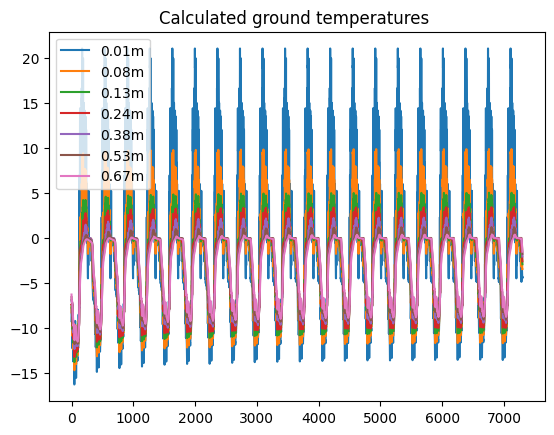

In [6]:
def load_calc():
    calc_file=WD_PATH/'out/result.txt'
    calc_data = np.loadtxt(calc_file, skiprows=0,  unpack=False)
    calc_header=['id','time','Tair','snow','0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m' ]
    df = pd.DataFrame(calc_data, columns=calc_header) 
    return df

df_calc = load_calc()

df_calc[['0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m']].plot()
plt.title('Calculated ground temperatures ')